In [1]:
import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import movingpandas as mpd
import shapely as shp
import hvplot.pandas
import matplotlib.pyplot as plt
import matplotlib.colors
import folium
import pint

ureg = pint.UnitRegistry()
ureg.setup_matplotlib(True)


In [2]:
ais_gdf = gpd.read_file('../data/ais.gpkg')

In [3]:
# check properties of the relevant variables
# here you might want to check for missing values and extreme values
# this dataset already seems to be cleaned up. 
ais_gdf[['SOG', 'COG']].describe()

,SOG,COG
count,84699.000000,84202.000000
mean,3.064408,171.512940
std,5.839462,117.313857
min,0.000000,0.000000
25%,0.000000,56.400000
50%,0.000000,191.000000
75%,4.500000,275.800000
max,43.300000,359.900000


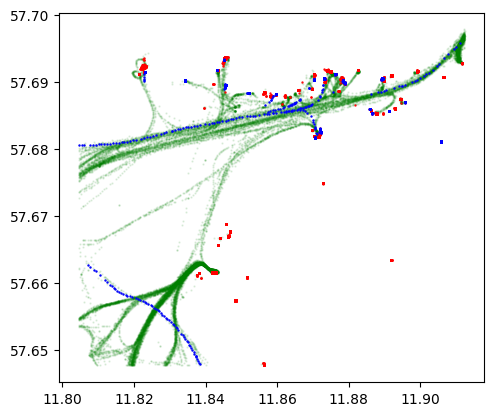

In [4]:
# Check if all zero speed over ground ships (red) are in a port
# They are all in the port or inland. So we can ignore them. 
fig, ax = plt.subplots()
ais_gdf[ais_gdf['SOG'] != 0].plot(color='green', ax=ax, alpha=0.1, markersize=0.5)
ais_gdf[ais_gdf['SOG'] == 0].plot(color='red', ax=ax, alpha=0.9, markersize=0.5)
# ships that are moored are not always moored, so let's ignore that
ais_gdf[ais_gdf['NavStatus'] == 'Moored'].plot(color='blue', ax=ax, markersize=0.5)
# filter and make a copy (because we'll add columns later)
ais_gdf = ais_gdf[ais_gdf['SOG'] > 0].copy()

<Axes: >

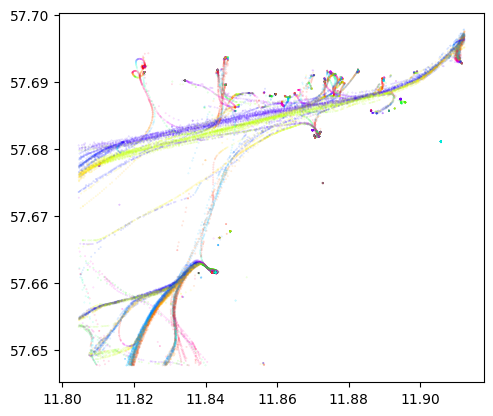

In [5]:
# Check if course over ground is consistent
N = matplotlib.colors.Normalize(0, 360)
cog = ais_gdf['COG']
cm = matplotlib.cm.hsv
rgba = cm(N(cog))
ais_gdf.plot(c=rgba, markersize=0.1, alpha=0.2)

In [48]:
# Time is in a local format. 
# Let's convert it to normal times
ais_gdf["t"] = pd.to_datetime(ais_gdf["Timestamp"], format="%d/%m/%Y %H:%M:%S")
ais_gdf['traj_id'] = ais_gdf['MMSI']
ais_gdf['obj_id'] = ais_gdf['MMSI']
traj_collection = mpd.TrajectoryCollection(
    ais_gdf.set_index('t'), 
    traj_id_col="traj_id", 
    obj_id_col="obj_id",
    min_length=100
)
traj_collection.add_speed(overwrite=True, units=('m', 's'))
traj_collection.add_direction(overwrite=True)


TrajectoryCollection with 77 trajectories

In [49]:
# sample trajectory to make sure we use correct angles
# deg2rad - 0 north -> 0 east

In [50]:
traj_collection.to_point_gdf().to_parquet('ais.parquet')
traj_collection.to_line_gdf().to_parquet('ais-line.parquet')

(0.0, 20.0)

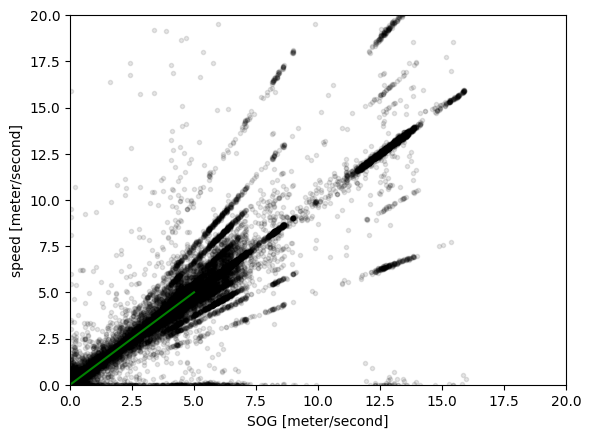

In [51]:
point_gdf = traj_collection.to_point_gdf()

sog = point_gdf['SOG'].values * ureg.knot
speed = point_gdf['speed'].values * (ureg.meter / ureg.second)

fig, ax = plt.subplots()
# units will be filled into the labels
ax.plot(sog.to('meter / second'), speed, 'k.', alpha=0.1)
ax.plot([0, 5], [0, 5], 'g-')
ax.set_xlabel(f"SOG [{ax.get_xlabel()}]")
ax.set_ylabel(f"speed [{ax.get_ylabel()}]")
ax.set_xlim(0, 20)
ax.set_ylim(0, 20)





Text(0, 0.5, 'direction [degree]')

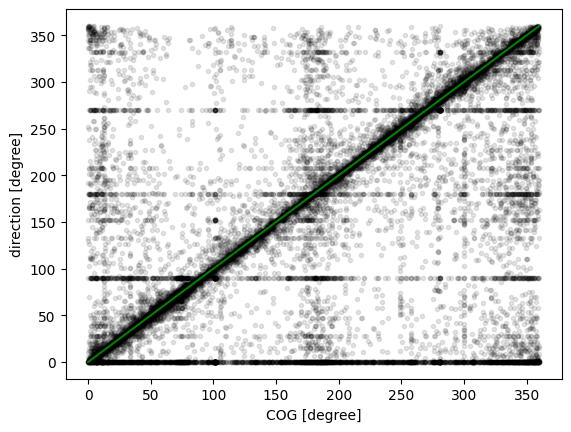

In [52]:
cog = point_gdf['COG'].values * ureg.degree
direction = point_gdf['direction'].values * ureg.degree

fig, ax = plt.subplots()
ax.plot(cog, direction, 'k.', alpha=0.1)
ax.plot([0, 360], [0, 360], 'g-')

ax.set_xlabel(f"COG [{ax.get_xlabel()}]")
ax.set_ylabel(f"direction [{ax.get_ylabel()}]")


In [64]:
# get the trajectory of these two ship
# 230957000
# 210035000

# ships were closest at around 17:45


# these ships were closest around 19:06
mmsi_a = 265550210
mmsi_b = 265410000

traj_a = traj_collection.get_trajectory(mmsi_a)
traj_b = traj_collection.get_trajectory(mmsi_b)
# traj_a
# traj_b
print(traj_a)

Trajectory 265550210 (2017-07-05 08:54:34 to 2017-07-05 19:27:25) | Size: 764 | Length: 15712.5m
Bounds: (11.805392, 57.647893, 11.882855, 57.693732)
LINESTRING (11.805392 57.676007, 11.805997 57.676248, 11.806605 57.676488, 11.807282 57.676748, 11.8


In [57]:
traj_collection_ab = mpd.TrajectoryCollection([traj_a, traj_b])

In [58]:
traj_collection_ab.hvplot()

:Overlay
   .WMTS.I    :WMTS   [Longitude,Latitude]
   .Path.I    :Path   [Longitude,Latitude]
   .Path.II   :Path   [Longitude,Latitude]
   .Points.I  :Points   [Longitude,Latitude]   (triangle_angle)
   .Points.II :Points   [Longitude,Latitude]   (triangle_angle)

<Axes: >

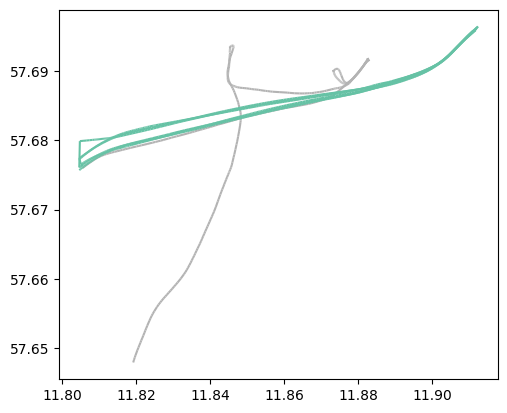

In [69]:
fig, ax = plt.subplots()
traj_collection_ab.plot(ax=ax, column='MMSI', cmap='Set2')